# Mathematical Engineering - Financial Engineering, FY 2024-2025
# Risk Management - Exercise 2: Corporate Bond Portfolio and Credit Single Factor Model

In [625]:
# Importing the libraries

import numpy as np
import pandas as pd
import pickle # added library 
from scipy.optimize import fsolve   
from scipy.stats import norm

from ex0_utilities import bootstrap, get_discount_factor_by_zero_rates_linear_interp
from date_functions import business_date_offset, year_frac_act_x
from ex2_utilities import (
    defaultable_bond_dirty_price_from_intensity,
    defaultable_bond_dirty_price_from_z_spread,
)

#### Import market data

In [626]:
# =============================================================================
# Bootstrap the discount curve from market data (Assignment 0)
# =============================================================================
dt = pd.read_csv('dt.csv',
                index_col = 'Market',
                usecols = ['Market','TARGET'],
                converters = {'TARGET':pd.to_datetime})

depo_converter = lambda x: float(x)
df_depos = pd.read_csv('depos.csv', 
                   index_col ='Depos',
                   usecols = ['Depos','ASK','BID'], 
                    converters={'Depos':pd.to_datetime,'BID':depo_converter,'ASK':depo_converter})

future_converter = lambda x: float(x)
futures = pd.read_csv('futures.csv',
                      index_col ='Futures',
                      usecols = ['Futures','ASK','BID'],
                      converters = {'Futures':pd.to_datetime, 'Settle':pd.to_datetime, 'Expiry':pd.to_datetime})
expiry = pd.read_csv('expiry.csv',
                     index_col = 'Futures',
                     usecols =['Futures', 'Settle', 'Expiry'], 
                     converters = {'Futures':pd.to_datetime, 'Settle':pd.to_datetime, 'Expiry':pd.to_datetime})
df_futures = futures.join(expiry)

swap_converter = lambda x: float(x)
df_swaps = pd.read_csv('swaps.csv',
                    index_col = 'Swaps',
                    usecols = ['Swaps','BID','ASK'],
                    converters={'Swaps':pd.to_datetime,'BID':swap_converter,'ASK':swap_converter})

today = dt.TARGET['Today']
settlement_date  = dt.TARGET['Settlement']

# Storing the data in a dictionary
market_data = dict()
market_data["reference_date"] = settlement_date
market_data["depo"] = df_depos
market_data["futures"] = df_futures
market_data["swaps"] = df_swaps
pickle.dump(market_data, open("market_data.p", "wb"))


# Bootstrap
discount_factors, zero_rates = bootstrap(settlement_date, df_depos, df_futures, df_swaps)

#### Portfolio A

In [627]:
# Parameters
maturity1 = 1  # Maturity in years
maturity2 = 2
notional1 = 1e7
notional2 = 1e7
coupon_rate1 = 0.055 #changed to decimal 
coupon_rate2 = 0.070 #changed to decimal 
coupon_freq1 = 2  # Coupon frequency in payments a years
coupon_freq2 = 2
dirty_price1 = 100.0
dirty_price2 = 103.0

recovery_rate = 0.40

rating = "IG"  # Credit rating

expiry1 = business_date_offset(today, year_offset=maturity1)
expiry2 = business_date_offset(today, year_offset=maturity2)


#### Z-spread

Price of defaultable bond, with coupon rate $c$ as function of the $z$-spread, ignoring the accrual:

$\hat{C}(t,T) = c\sum_{n=1}^N \delta_n\hat{B}(t,t_n)+\hat{B}(t,t_N)$

where 
- $\hat{B}(t,t_n) = B(t,t_n) \exp{ \{-\int_t^{t_n} z(s)ds\} }$

#### Q1: Z-spread calculation, assumed constant

In [628]:
z_spread_1y = fsolve(
    lambda z_spread: defaultable_bond_dirty_price_from_z_spread(
        settlement_date,  #fixed
        settlement_date,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        z_spread[0],
        discount_factors,
        100,    
    )
    - dirty_price1,
    x0=0.02, #initial guess, to initialize root finder 
)[0]

z_spread_2y = fsolve(
    lambda z_spread: defaultable_bond_dirty_price_from_z_spread(
        settlement_date,
        settlement_date,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        z_spread[0],
        discount_factors,
        100,    
    )
    - dirty_price2,
    x0=0.02, #initial guess, to initialize root finder 
)[0]

print(f"Z-spread over {maturity1}y: {z_spread_1y:.6%}")
print(f"Z-spread over {maturity2}y: {z_spread_2y:.6%}")

Z-spread over 1y: 1.476137%
Z-spread over 2y: 1.522951%


#### Intensity

Price of defaultable bond, with coupon rate $c$ and recovery rate $\pi$, ignoring the accrual:

$\bar{C}(t,T) = c\sum_{n=1}^N \delta_n\bar{B}(t,t_n)+\bar{B}(t,t_N) +\pi \sum_{n=1}^N e(t;t_{n-1},t_n)$

where 

- $\bar{B}(t,T) = B(t,T) P(t,T)$ is the price of a defaultable zero coupon bond
- $P(t,T)=\exp{\{-\int_t^T \lambda(s)ds\}}$ is the survival probability up to time $T$, with $\lambda(s)$ intensity
- $e(t;t_{n-1},t_n)=B(t,t_n)(P(t,t_{n-1})-P(t,t_n))$ where $P(t,t_{n-1})-P(t,t_n)$ is the default probability between $t_{n-1}$ and $t_n$

#### Q2: Derive the average intensities for the two bonds and default probabilities

In [629]:
# Intensities average
h_1y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        settlement_date,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price1,
    x0=0.02,
)[0]

h_2y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        settlement_date,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price2,
    x0=0.02,
)[0]
  
print(f"Average intensity over {maturity1}y: {h_1y:.6%}")
print(f"Average intensity over {maturity2}y: {h_2y:.6%}")

Average intensity over 1y: 2.421852%
Average intensity over 2y: 2.469442%


In [630]:
# Survival probabilities

surv_prob_1y = np.exp(- h_1y *  maturity1) 
surv_prob_2y = np.exp(- h_2y *  maturity2) 

# Defaul probabilities
default_prob_1y = 1 - surv_prob_1y
default_prob_2y = 1 - surv_prob_2y

print(f"{maturity1}y default probability: {default_prob_1y:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y:.6%}")

1y default probability: 2.392760%
2y default probability: 4.818905%


#### Q3: Default probability estimates under the hp. of piecewise constant intensity

In [631]:
# Intensities piecewise

h_1y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        settlement_date,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price1,
    x0=0.02,
)[0]

h_1y2y = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        settlement_date,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        pd.Series({expiry1: h_1y, expiry2: float(intensity[0])}),  # piecewise Series
        discount_factors,
        100,
    )
    - dirty_price2,
    x0=0.02,
)[0]

print(f"Piecewise constant intensity over {maturity1}y: {h_1y:.6%}")
print(f"Piecewise constant intensity over {maturity2}y: {h_1y2y:.6%}")


Piecewise constant intensity over 1y: 2.421852%
Piecewise constant intensity over 2y: 2.547740%


Text(0.5, 1.0, 'Intensity')

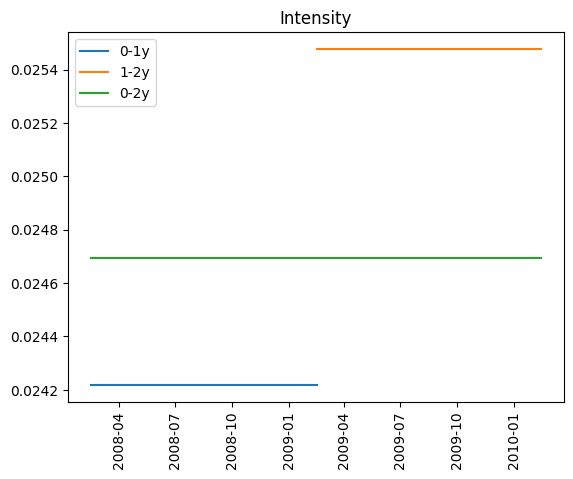

In [632]:
import matplotlib.pyplot as plt

plt.plot([today, expiry1], [h_1y, h_1y])
plt.plot([expiry1, expiry2], [h_1y2y, h_1y2y])
plt.plot([today, expiry2], [h_2y, h_2y])
plt.xticks(rotation=90)
plt.legend([f"0-{maturity1}y", f"{maturity1}-{maturity2}y", f"0-{maturity2}y"])
plt.title("Intensity")

In [633]:
# Survival probabilities

surv_prob_1y = np.exp(- h_1y *  maturity1) 
surv_prob_2y = surv_prob_1y * np.exp(-h_1y2y * 1 )

# Defaul probabilities

default_prob_1y = 1 - surv_prob_1y
default_prob_2y = 1 - surv_prob_2y

print(f"{maturity1}y default probability: {default_prob_1y:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y:.6%}")

1y default probability: 2.392760%
2y default probability: 4.848128%


#### Q4: Estimate the default probabilities under a shock of the mid-term creditworthiness

In [634]:
dirty_price1_shock = dirty_price1
dirty_price2_shock = 97.0

# Choosing piecewise constant intensity because it's a better approximation

h_1y_shock = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        settlement_date,
        maturity1,
        coupon_rate1,
        coupon_freq1,
        recovery_rate,
        intensity[0],
        discount_factors,
        100,
    )
    - dirty_price1_shock,
    x0=0.02,
)[0]

h_1y2y_shock = fsolve(
    lambda intensity: defaultable_bond_dirty_price_from_intensity(
        settlement_date,
        settlement_date,
        maturity2,
        coupon_rate2,
        coupon_freq2,
        recovery_rate,
        pd.Series({expiry1: h_1y, expiry2: float(intensity[0])}),  # piecewise Series
        discount_factors,
        100,
    )
    - dirty_price2_shock,
    x0=0.02,
)[0]


# Survival probabilities
surv_prob_1y_shock = np.exp(- h_1y_shock *  maturity1) 
surv_prob_2y_shock = surv_prob_1y_shock * np.exp(-h_1y2y_shock * 1 )

# Defaul probabilities

default_prob_1y_shock = 1 - surv_prob_1y_shock
default_prob_2y_shock = 1 - surv_prob_2y_shock

print(f"{maturity1}y default probability: {default_prob_1y_shock:.6%}")
print(f"{maturity2}y default probability: {default_prob_2y_shock:.6%}")

1y default probability: 2.392760%
2y default probability: 14.832230%


#### Q5: Real world default probability from the rating transition matrix

In [635]:
# rating transition matrix at 1y
transition_matrix = pd.DataFrame(
    [[0.73, 0.25, 0.02], [0.35, 0.6, 0.05], [0, 0, 1]],
    index=["IG", "HY", "Def"],
    columns=["IG", "HY", "Def"],
)

transition_matrix_2y = transition_matrix @ transition_matrix # useed @ not *

print(
    f"One year real world default probability: {transition_matrix.at[rating, 'Def']:.2%}"
)
print(
    f"Two year real world default probability: {transition_matrix_2y.at[rating, 'Def']:.2%}"
)

# Real world: from transition matrix
conditional_real_default_prob_1y2y = (transition_matrix_2y.at[rating,"Def"] - transition_matrix.at[rating,"Def"] ) / (1 - transition_matrix.at[rating, "Def"])
conditional_implied_default_prob_1y2y = (default_prob_2y_shock - default_prob_1y_shock ) / (1-default_prob_1y_shock)

print(
    f"Real world conditional default probability: {conditional_real_default_prob_1y2y:.2%}"
)
print(
    f"Implied conditional default probability: {conditional_implied_default_prob_1y2y:.2%}"
)

One year real world default probability: 2.00%
Two year real world default probability: 4.71%
Real world conditional default probability: 2.77%
Implied conditional default probability: 12.74%


#### Q6: Bond portfolio priced with transition matrix
One year IG zero-coupon bond

$\bar{B}^{IG}(t,t_1)=(1-\pi_{1,3})B(t,t_1) + \pi_{1,3} B(t,t_1/2)\eta$

Two years IG zero-coupon bond

$\bar{B}^{IG}(t,t_2)=\pi_{1,1}B(t,t_1)\bar{B}^{IG}(t_1,t_2) + \pi_{1,2}B(t,t_1)\bar{B}^{HY}(t_1,t_2)+\pi_{1,3}B(t,t_1/2) \eta$

where:
- $\eta$ is the recovery
- $\bar{B}^{IG}(t_1,t_2)$ is the forward zero coupon bond IG
- $\bar{B}^{HY}(t_1,t_2)$ is the forward zero coupon bond HY

In [636]:
# Parameters
issuers_num = 100  # Number of bonds in the portfolio
maturity = 2  # Maturity in years

rating = "IG"  # Credit rating

expiry = business_date_offset(today, year_offset=maturity)

# Same matrix as before
transition_matrix = pd.DataFrame(
    [[0.73, 0.25, 0.02], [0.35, 0.6, 0.05], [0, 0, 1]],
    index=["IG", "HY", "Def"],
    columns=["IG", "HY", "Def"],
)

recovery_rate = 0.4
face_value = 1_000_000   # of each bond
rho = [0.0, 0.25, 0.50]
mc_simulations = 1_000_000

In [637]:
# a) Portfolio MtM assuming all issuers IG

# Get all the relevant discount factors


df_expiry = get_discount_factor_by_zero_rates_linear_interp(
    today,
    business_date_offset(today, year_offset=2),  # "average" time of default, if default is between today and 1y
    discount_factors.index,
    discount_factors.values,
)

df_2y_def = get_discount_factor_by_zero_rates_linear_interp(
    today, business_date_offset(today, month_offset= 18),
    discount_factors.index, discount_factors.values
)

# We consider the default at the midpoint
df_1y_def = get_discount_factor_by_zero_rates_linear_interp(
    today,
    business_date_offset(today, month_offset=6),  # "average" time of default, if default is between today and 1y
    discount_factors.index,
    discount_factors.values,
)


transition_matrix_2y = transition_matrix @ transition_matrix #


survival_prob_1y = transition_matrix.loc[rating, ["IG", "HY"]].sum()
survival_prob_2y = transition_matrix_2y.loc[rating, ["IG", "HY"]].sum()

bond_mtm = survival_prob_2y * df_expiry + recovery_rate * (1 - survival_prob_1y) * df_1y_def + recovery_rate * (survival_prob_1y - survival_prob_2y) * df_2y_def

ptf_mtm = issuers_num * face_value * bond_mtm
print(f"Portfolio MtM: €{ptf_mtm:,.2f}")

Portfolio MtM: €90,176,235.60


In [638]:
# b) Evaluate the present value in 1 year time under various scenarios

ref_date = business_date_offset(today, year_offset=1)


df_expiry =  get_discount_factor_by_zero_rates_linear_interp(
    today,
    business_date_offset(today, year_offset=2),  # "average" time of default, if default is between today and 1y
    discount_factors.index,
    discount_factors.values,
) 

df_ref_date = get_discount_factor_by_zero_rates_linear_interp(
    today,
    business_date_offset(today, year_offset=1),  # "average" time of default, if default is between today and 1y
    discount_factors.index,
    discount_factors.values,
)

fwd_df = df_expiry / df_ref_date          # forward discount factor B(reference_date,expiry)
fwd_df_1y_def = df_2y_def / df_ref_date   # forward discount factor B(reference_date,"avg" default date)

survival_prob_ig_1y = transition_matrix.loc["IG", ["IG", "HY"]].sum()
survival_prob_hy_1y = transition_matrix.loc["HY", ["HY", "IG"]].sum()

fwd_price_ig = fwd_df * survival_prob_ig_1y + recovery_rate * (1 - survival_prob_ig_1y) * fwd_df_1y_def
fwd_price_hy = fwd_df * survival_prob_hy_1y + recovery_rate * (1 - survival_prob_hy_1y) * fwd_df_1y_def

fwd_price = (
    fwd_price_ig * transition_matrix.at["IG", "IG"]
    + fwd_price_hy * transition_matrix.at["IG", "HY"]
    + recovery_rate * transition_matrix.at["IG", "Def"] * (fwd_df_1y_def/ df_ref_date) # modified pr0va cancelled fwd_df  
)

print("Fwd priceIG: ",fwd_price_ig)
print("Fwd priceHY: ",fwd_price_hy)
print("Fwd price: ",fwd_price)


Fwd priceIG:  0.9529401281187182
Fwd priceHY:  0.9358047943877997
Fwd price:  0.9377750142086705


In [639]:
# c) Monte Carlo simulation
# Barriers and PnL for a single IG issuer

barrier_default = norm.ppf(transition_matrix.at[rating,"Def"])
barrier_downgrade = norm.ppf(transition_matrix.at["IG", "HY"] + transition_matrix.at["IG", "Def"])
barrier_upgrade = np.inf  # IG name can't be upgraded

loss_given_default =  (fwd_df_1y_def/ df_ref_date)*recovery_rate - fwd_price
loss_given_downgrade = fwd_price_hy - fwd_price
loss_status_quo = fwd_price_ig - fwd_price
loss_upgrade = 0     # upgrade from ig is not possible

In [640]:
# 3 correlation scenarios
# to have the same result at each run, fix the seed
np.random.seed(23)
y = np.random.normal(size=(mc_simulations, 1))
eps = np.random.normal(size=(mc_simulations, issuers_num))

# Adding correlation
r = rho[0] # repeat with rho[1] and rho[2] or try to do all together: array can have n-dimensions
v = r * y + np.sqrt(1 - r**2) * eps   # changed formula: before it was v = np.sqrt(r) * y + np.sqrt(1 - r) * eps


In [641]:
# count of defaults, downgrades, upgrades in each simulation...

defaults = (v < barrier_default).sum(axis=1)
downgrades = ((v >= barrier_default) & (v < barrier_downgrade)).sum(axis=1)
status_quo = issuers_num - defaults - downgrades  
upgrades = np.zeros(mc_simulations)

print(f"Average defaults: {defaults.mean()}")
print(f"Average downgrades: {downgrades.mean()}")


Average defaults: 1.997994
Average downgrades: 24.997188


In [642]:
# Marginal distributions (check)
prob_default = defaults.mean() / issuers_num
prob_downgrade = downgrades.mean() / issuers_num   # considering also IG -> DEF as downgrades
prob_status_quo = status_quo.mean() / issuers_num
prob_upgrades = upgrades.mean() / issuers_num

In [643]:
# Evaluating the one-year 99% VaR by taking into account defaults only/defaults and rating changes:
defaults_only = False
     # change to True to obtain Var and expected_loss in case of defaults only 

if defaults_only:
    scenario = defaults * loss_given_default
else:
    scenario =(defaults * loss_given_default
        + downgrades  * loss_given_downgrade
        + status_quo * loss_status_quo
        + upgrades * loss_upgrade 
    )

VaR = -np.quantile(scenario, 0.01) * face_value   # corrected 0.001 --> 0.01
expected_loss = - scenario.mean() * face_value

print(f"Expected loss: {expected_loss:,.2f}€")
print(f"VaR: {VaR:,.2f}€")

Expected loss: -1,139.58€
VaR: 2,159,120.76€


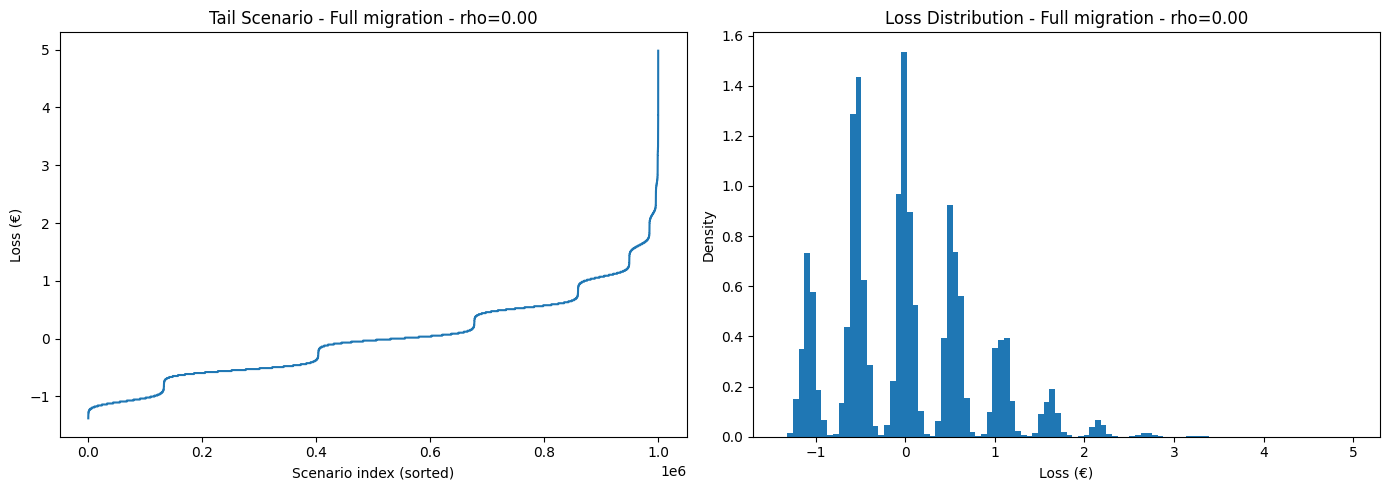

In [644]:
# changed the plot, the three plots are in the report :)
import matplotlib.pyplot as plt


scenario_loss = [-s for s in scenario]  # flip sign: positive = loss
scenario_loss.sort()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Tail Scenario
ax1.plot(scenario_loss)
ax1.set_title("Tail Scenario - Full migration - rho=0.00")
ax1.set_xlabel("Scenario index (sorted)")
ax1.set_ylabel("Loss (€)")

# Right: Loss Distribution
ax2.hist(scenario_loss, bins=100, density=True)
ax2.set_title("Loss Distribution - Full migration - rho=0.00")
ax2.set_xlabel("Loss (€)")
ax2.set_ylabel("Density")

plt.tight_layout()
plt.show()